# Import des données issues de la base SIRENE pour les établissements du lien social

Bibliothèques

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Import des données

Définition des catégories d'établissements à importer. Cela concernant les établissements pouvant être catégorisés comme créant un lien social.

In [32]:
code_etab = [
    # 55.1A (avec resto), 55.1C (sans resto), 55.1D (préfecture), 55.1E (auberges) sont devenus 55.10Z
    "55.10Z", "55.1A", "55.1C", "55.1D", "55.1E", 
    
    # 55.2C est devenu 55.30Z
    "55.30Z", "55.2C",
    
    # 55.3A est devenu 56.10A
    "56.10A", "55.3A",
    
    # 55.4A (Cafés tabacs) et 55.4B (Débits de boissons) sont devenus 56.30Z
    "56.30Z", "55.4A", "55.4B", 
    
    # 52.4L (livres) est devenu 47.61Z
    "47.61Z", "52.4L",
    
    # 52.4R (presse/papeterie) est devenu 47.62Z
    "47.62Z", "52.4R"
]

Import des données brutes

In [33]:
chunks = []
# 1. On force le type 'str' (texte) pour éviter que Pandas supprime les zéros du début
types_dict = {
    'siret': str,
    'codeCommuneEtablissement': str,
    'codeCommune2Etablissement': str,
    'activitePrincipaleEtablissement': str,
    'etatAdministratifEtablissement': str,
    'trancheEffectifsEtablissement' : str,
}
print("Lecture du fichier par blocs en cours...")
# 2. Lecture par chunks
for chunk in pd.read_csv(
    r"C:\Users\yancr\Downloads\StockEtablissement_utf8\StockEtablissement_utf8.csv", 
    chunksize=100000, 
    usecols=[
        'activitePrincipaleEtablissement',
        'codeCommuneEtablissement', 'dateCreationEtablissement',
        'siret', 'etatAdministratifEtablissement', 'dateDebut','trancheEffectifsEtablissement'
    ],
    dtype=types_dict
):
    # Filtre sur les codes d'activité souhaités
    chunk_filtre = chunk[chunk['activitePrincipaleEtablissement'].isin(code_etab)]
    chunks.append(chunk_filtre)

# 3. On recolle les morceaux à la fin
df = pd.concat(chunks, ignore_index=True)
print(f"Terminé ! Nombre d'établissements conservés : {len(df)}")

Lecture du fichier par blocs en cours...
Terminé ! Nombre d'établissements conservés : 1067274


## Traitement des données manquantes

### 1 Gestion des établissements fermés sans date indiquées

On commence par regarder combien d'établissements sont concernés.

In [34]:
df.loc[(df['dateDebut'].isna()) & (df['etatAdministratifEtablissement'] == 'F')].count()

siret                              1321
dateCreationEtablissement             1
trancheEffectifsEtablissement      1321
codeCommuneEtablissement           1320
dateDebut                             0
etatAdministratifEtablissement     1321
activitePrincipaleEtablissement    1321
dtype: int64

On enleve ces établissements

In [35]:
df = df[
    ~(
        (df['dateDebut'].isna()) &
        (df['etatAdministratifEtablissement'] == 'F')
    )
]

print(f"Terminé ! Nombre d'établissements conservés : {len(df)}")

Terminé ! Nombre d'établissements conservés : 1065953


### 2 Gestion des établissements fermés manuellement

Nombre des établissements fermés au 1er janvier de chaque année 

In [37]:
for annee in range(1995, 2023):
    # On filtre les lignes et on compte leur nombre avec len()
    nb_etablissements = len(df[(df['dateDebut'] == f'{annee}-01-01') & (df['etatAdministratifEtablissement'] == 'F')])
    
    print(f"{annee} : {nb_etablissements}")

1995 : 184
1996 : 205
1997 : 261
1998 : 195
1999 : 231
2000 : 255
2001 : 291
2002 : 249
2003 : 261
2004 : 394
2005 : 438
2006 : 315
2007 : 288
2008 : 11270
2009 : 295
2010 : 367
2011 : 266
2012 : 307
2013 : 273
2014 : 365
2015 : 241
2016 : 429
2017 : 402
2018 : 264
2019 : 344
2020 : 283
2021 : 242
2022 : 354


N'ayant pas acces à la date réelle de fermeture des établissements au 1er janvier 2008 (surplus du au changement de nomenclature), on décide les supprimer de la base.

In [52]:
df = df[~(df['dateDebut'] == '2008-01-01')]

### 3 Exploration de la construction des données

Cette partie va permettre de justifier la création d'un de données SIRENE annuelle uniquement. En effet, on notera que les fermetures d'établissements contiennent des discontinuités à certaines périodes : en toute fin ou tout début d'années, à chaque fin de trimestre ainsi qu'en début, milieu et fin de mois.

Graphique montrant l'évolution du nombre de fermetures en fonction du jour du mois entre 1995 et 2022

<Axes: title={'center': 'Répartition administrative des fermetures'}, xlabel='jour_du_mois'>

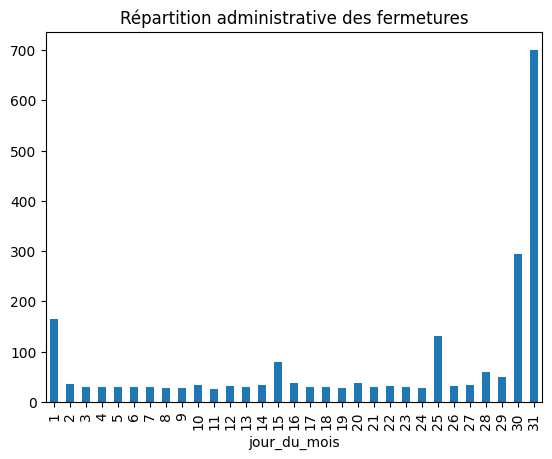

In [42]:
# 1. Préparation des dates
df['dateDebut'] = pd.to_datetime(df['dateDebut'], errors='coerce')

# 2. Filtrage global (1995 à 2022 + Fermetures)
df_periode = df[
    (df['dateDebut'].dt.year >= 1995) & 
    (df['dateDebut'].dt.year <= 2022) & 
    (df['etatAdministratifEtablissement'] == 'F')
].copy()

# 3. Extraction du jour du mois
df_periode['jour_du_mois'] = df_periode['dateDebut'].dt.day

# 4. Calcul en deux étapes pour une moyenne rigoureuse :
# Étape A : On compte les fermetures pour chaque date réelle (ex: combien le 01/01/2007, le 01/02/2007...)
comptage_par_date = df_periode.groupby(['dateDebut', 'jour_du_mois']).size().reset_index(name='nb')

# Étape B : On fait la moyenne par rang de jour (Moyenne de tous les "1er", tous les "2", etc.)
moyenne_globale = comptage_par_date.groupby('jour_du_mois')['nb'].mean()

# 5. visualisation
moyenne_globale.plot(kind='bar', title='Répartition administrative des fermetures')

Graphique montrant l'évolution du nombre de fermetures la dernière semaine du mois, en fonction du mois, entre 1995 et 2022

<Axes: title={'center': 'Nombre moyen de fermetures la dernière semaine du mois (1995-2022)'}>

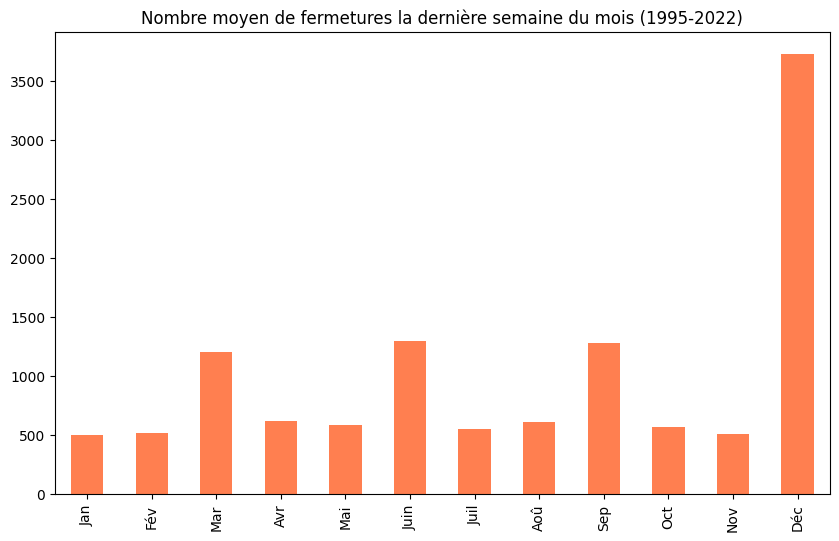

In [43]:
# 1. Préparation des dates
df['dateDebut'] = pd.to_datetime(df['dateDebut'], errors='coerce')

# 2. Filtrage global (1995 à 2022 + Fermetures uniquement)
df_periode = df[
    (df['dateDebut'].dt.year >= 1995) & 
    (df['dateDebut'].dt.year <= 2022) & 
    (df['etatAdministratifEtablissement'] == 'F')
].copy()

# 3. Filtrage de la dernière semaine du mois
# On récupère le nombre de jours total dans le mois de chaque date
jours_dans_le_mois = df_periode['dateDebut'].dt.days_in_month

# On ne garde que les dates qui tombent dans les 7 derniers jours du mois
df_derniere_semaine = df_periode[df_periode['dateDebut'].dt.day >= (jours_dans_le_mois - 6)].copy()

# 4. Extraction du mois et de l'année
df_derniere_semaine['annee'] = df_derniere_semaine['dateDebut'].dt.year
df_derniere_semaine['mois'] = df_derniere_semaine['dateDebut'].dt.month

# 5. Calcul en deux étapes pour la rigueur statistique :
# Étape A : Comptage des fermetures (de la dernière semaine) pour chaque couple (Année, Mois)
# Ex: Combien en fin janv 2002, fin fév 2002, ..., fin janv 2003, etc.
comptage_par_annee_mois = df_derniere_semaine.groupby(['annee', 'mois']).size().reset_index(name='nb')

# Étape B : On agrège par mois de l'année
# Note : Utilisez .mean() pour la moyenne annuelle, ou .sum() pour le cumul total sur les 20 ans
resultat_par_mois = comptage_par_annee_mois.groupby('mois')['nb'].mean()

# Optionnel : Remplacer les numéros (1-12) par le nom des mois pour le graphique
noms_mois = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
resultat_par_mois.index = noms_mois

# 6. Visualisation
plt.figure(figsize=(10, 6))
resultat_par_mois.plot(
    kind='bar', 
    color='coral',
    title='Nombre moyen de fermetures la dernière semaine du mois (1995-2022)'
)

Graphique montrant l'évolution du nombre de fermetures la première semaine du mois, en fonction du mois, entre 1995 et 2022

<Axes: title={'center': 'Nombre moyen de fermetures la dernière semaine du mois (1995-2022)'}>

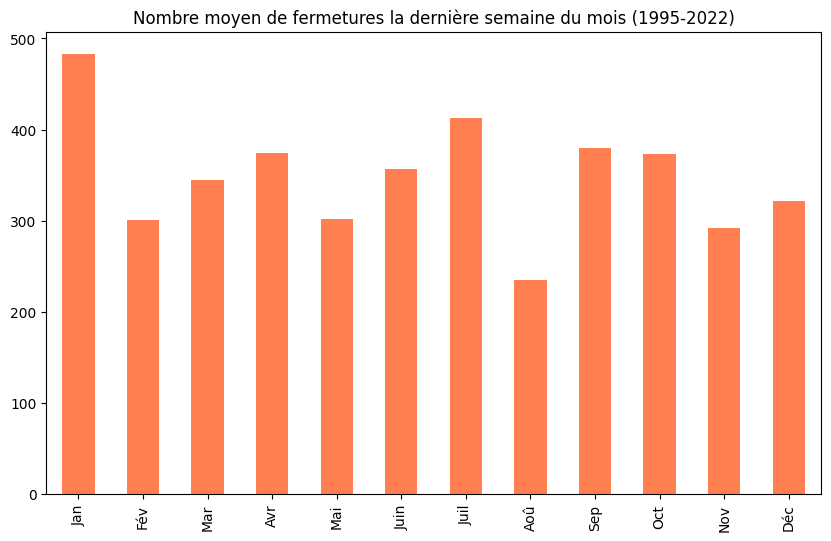

In [44]:
# 1. Préparation des dates
df['dateDebut'] = pd.to_datetime(df['dateDebut'], errors='coerce')

# 2. Filtrage global (1995 à 2022 + Fermetures uniquement)
df_periode = df[
    (df['dateDebut'].dt.year >= 1995) & 
    (df['dateDebut'].dt.year <= 2022) & 
    (df['etatAdministratifEtablissement'] == 'F')
].copy()

# 3. Filtrage de la première semaine du mois

# On ne garde que les dates qui tombent dans les 7 derniers jours du mois
df_derniere_semaine = df_periode[df_periode['dateDebut'].dt.day.isin(range(1,8))].copy()

# 4. Extraction du mois et de l'année
df_derniere_semaine['annee'] = df_derniere_semaine['dateDebut'].dt.year
df_derniere_semaine['mois'] = df_derniere_semaine['dateDebut'].dt.month

# 5. Calcul en deux étapes pour la rigueur statistique :
# Étape A : Comptage des fermetures (de la dernière semaine) pour chaque couple (Année, Mois)
# Ex: Combien en fin janv 2002, fin fév 2002, ..., fin janv 2003, etc.
comptage_par_annee_mois = df_derniere_semaine.groupby(['annee', 'mois']).size().reset_index(name='nb')

# Étape B : On agrège par mois de l'année
# Note : Utilisez .mean() pour la moyenne annuelle, ou .sum() pour le cumul total sur les 20 ans
resultat_par_mois = comptage_par_annee_mois.groupby('mois')['nb'].mean()

# Optionnel : Remplacer les numéros (1-12) par le nom des mois pour le graphique
noms_mois = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
resultat_par_mois.index = noms_mois

# 6. Visualisation
plt.figure(figsize=(10, 6))
resultat_par_mois.plot(
    kind='bar', 
    color='coral',
    title='Nombre moyen de fermetures la dernière semaine du mois (1995-2022)'
)

## Construction d'une base annualisée

On commence par modifier le DataFrame pour renseigner la date de création et de fermtures de chaque établissement

In [45]:
# 1. Sécurisation des formats : on s'assure que les colonnes d'origine sont bien des dates
df['dateCreationEtablissement'] = pd.to_datetime(df['dateCreationEtablissement'], errors='coerce')
df['dateDebut'] = pd.to_datetime(df['dateDebut'], errors='coerce')

# 2. Création de 'date_creation' (copie simple)
df['date_creation'] = df['dateCreationEtablissement']

# 3. Création de 'date_fermeture'
# On initialise la colonne avec des valeurs nulles (NaT = Not a Time)
df['date_fermeture'] = pd.NaT

# On remplit la date de fermeture avec 'dateDebut' UNIQUEMENT pour les établissements fermés ('F')
df.loc[df['etatAdministratifEtablissement'] == 'F', 'date_fermeture'] = df['dateDebut']

# Affichage des premières lignes pour vérifier le résultat
colonnes_a_verifier = ['siret', 'etatAdministratifEtablissement', 'date_creation', 'date_fermeture']
print(df[colonnes_a_verifier].head())

            siret etatAdministratifEtablissement date_creation date_fermeture
0  00541050100018                              F    1954-01-01     2001-12-31
1  00541066700017                              F           NaT     1996-10-30
2  00544081300029                              F           NaT     1989-12-31
3  00545011900036                              F    1994-05-01     2021-12-01
4  00547062000013                              F           NaT     1993-03-31


Comptabiliation des équipements par communes et par années 

Pour prendre en compte le surplus de fermetures chaque 1er janvier, on comptabilise les équipements de chaque années du 2 janvier au 1er janvier (inclus) de l'année suivante

In [46]:
df_prov = df.copy()

In [47]:
# S'assurer que les colonnes sont bien au format datetime
df_prov['date_creation'] = pd.to_datetime(df_prov['date_creation'], errors='coerce')
df_prov['date_fermeture'] = pd.to_datetime(df_prov['date_fermeture'], errors='coerce')

resultats = []
annees_etude = range(1995, 2023) # On stocke la plage d'années dans une variable

# Boucle de comptage (inchangée)
for annee in annees_etude:
    debut_periode = pd.Timestamp(f"{annee}-01-02")
    fin_periode = pd.Timestamp(f"{annee+1}-01-01")
    
    masque = (
        (df_prov['date_creation'] <= fin_periode) & 
        ((df_prov['date_fermeture'] > debut_periode) | df_prov['date_fermeture'].isna())
    )
    
    temp = df_prov[masque].groupby(['codeCommuneEtablissement', 'activitePrincipaleEtablissement']).size().reset_index(name='nombre')
    temp['Annee'] = annee
    resultats.append(temp)
    
if not resultats:
    print("Aucun résultat trouvé pour ces paramètres.")

df_bpe_temporelle = pd.concat(resultats, ignore_index=True)

# 1. Pivot pour obtenir le format BPE (attention, on garde l'index pour le moment)
df_sirene = df_bpe_temporelle.pivot_table(
    index=['codeCommuneEtablissement', 'Annee'],
    columns='activitePrincipaleEtablissement',
    values='nombre',
    fill_value=0
)

# --- ÉTAPE D'ÉQUILIBRAGE DU PANEL ---

# 2. Récupérer la liste complète et unique de toutes les communes de votre base
toutes_communes = df_prov['codeCommuneEtablissement'].dropna().unique()

# 3. Créer un index parfait (Toutes les communes X Toutes les années)
index_parfait = pd.MultiIndex.from_product(
    [toutes_communes, annees_etude], 
    names=['codeCommuneEtablissement', 'Annee']
)

# 4. Réindexer le dataframe sur cet index parfait.
# Les combinaisons Commune/Année qui manquaient sont créées et remplies de 0.
df_sirene = df_sirene.reindex(index_parfait, fill_value=0).reset_index()

# ------------------------------------

df_sirene.columns.name = None # Nettoyage esthétique

print("✅ Base générée avec succès avec un panel équilibré pour toutes les communes/années !")

✅ Base générée avec succès avec un panel équilibré pour toutes les communes/années !


Regroupement des catégories

Jusqu'ici, les établissements sont comptabilisée selon deux versions de la nomenclature NAF. On vient regrouper les établissements à l'aide d'une table de passage (table fournie par l'INSEE directement)

In [48]:
# 1. Définition du dictionnaire de regroupement (Mapping + Libellés)
# Clé = Nouvel intitulé de colonne, Valeur = Liste des colonnes actuelles à sommer
regroupement = {
    # 55.1A (avec resto), 55.1C (sans resto), 55.1D (préfecture), 55.1E (auberges) sont devenus 55.10Z
    "Hôtels et hébergement": ["55.10Z", "55.1A", "55.1C", "55.1D", "55.1E"], 
    
    # 55.2C est devenu 55.30Z
    "Campings": ["55.30Z", "55.2C"],
    
    # 55.3A est devenu 56.10A
    "Restauration traditionnelle": ["56.10A", "55.3A"],
    
    # 55.4A (Cafés tabacs) et 55.4B (Débits de boissons) sont devenus 56.30Z
    "Débits de boissons": ["56.30Z", "55.4A", "55.4B"], 
    
    # 52.4L (livres) est devenu 47.61Z
    "Librairie": ["47.61Z", "52.4L"],
    
    # 52.4R (presse/papeterie) est devenu 47.62Z
    "Presse et papeterie": ["47.62Z", "52.4R"]
}

# 2. Création des nouvelles colonnes sommées
# On ne prend que les colonnes qui existent réellement dans ton DF pour éviter les erreurs
for nom_final, colonnes_sources in regroupement.items():
    cols_presentes = [c for c in colonnes_sources if c in df_sirene.columns]
    if cols_presentes:
        df_sirene[nom_final] = df_sirene[cols_presentes].sum(axis=1)

# 3. Nettoyage : On ne garde que les colonnes d'identification et les nouveaux libellés
colonnes_id = ['codeCommuneEtablissement', 'Annee']
nouvelles_colonnes = list(regroupement.keys())

df_sirene = df_sirene[colonnes_id + nouvelles_colonnes].copy()


Visualisations graphiques par catégories. Ces visualisations nous permettent de constater de fort rattrapages à la fin des années 90 surement dus au changement de nomenclature qui a pu prendre plusieurs années à se boucler et entrainer ces 'cassures'. Les données ne sont donc exploitables qu'à partir de la fin des années 90.

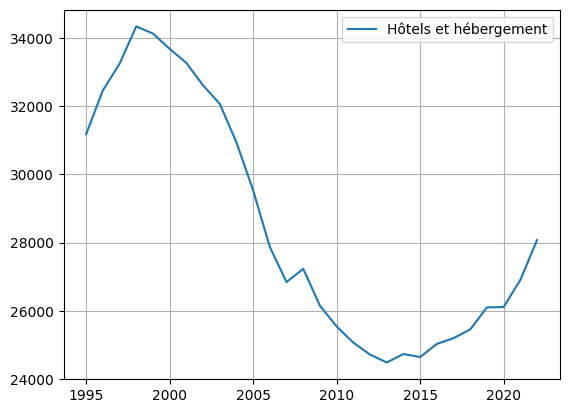

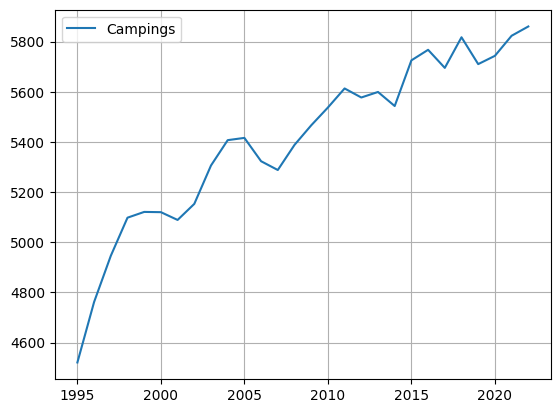

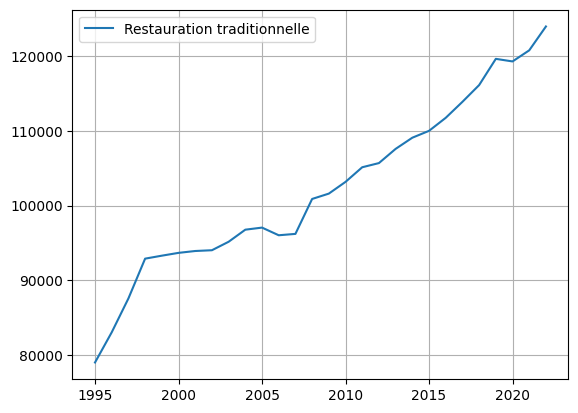

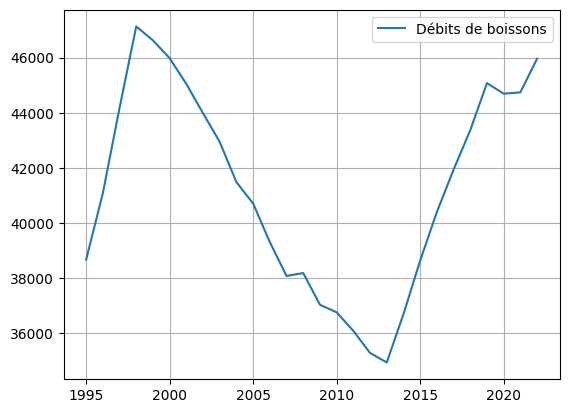

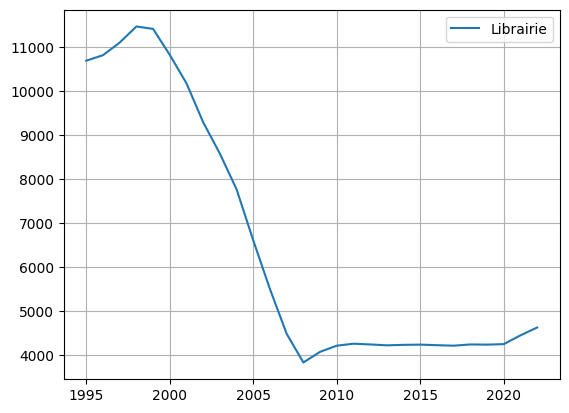

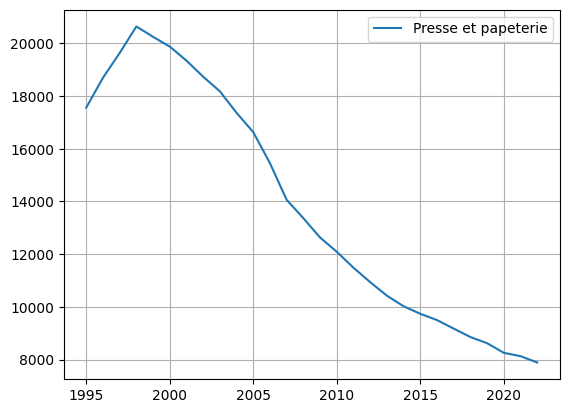

In [49]:
for code in df_sirene.columns[2:] :
    nb_etab = []

    for i in range (1995,2023) :
        nb_etab.append(df_sirene.loc[df_sirene['Annee']==i, code].sum())

    plt.plot(range (1995,2023), nb_etab, label=code)
    plt.grid()
    plt.legend()
    plt.show()

In [50]:
df_sirene.to_csv("Sirene_social.csv")